<a href="https://colab.research.google.com/github/VioletteGL/Interpretabiidad-y-Causalidad-Bourbaki/blob/main/I%26C2026RETO_RedesBayesianas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RETO módulo IV: DAG, Redes Bayesianas y D-Separación

In [ ]:
###
!pip install pyagrum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pandas as pd
from IPython.display import display, HTML

# Utilizarás los siguientes archivos:

1.   alarm.bif  
2.   dic_alarm.csv

- El archivo .bif es un archivo tipo **"Bayesian Interchange Format"**, el cual es un formato estándar basado en texto para almacenar y compartir Redes Bayesianas. En este archivo viene ya la red Bayesiana.
- el .csv trae información de cada variable con los siguientes campos: nombre, descripción, clase ('Evidencia', 'Alarma', 'Variable Inferida')

(En realidad cualquier variable puede ser la variable inferida, aquí solamente estamos asignando un papel)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargamos la Red Bayesiana
bn = gum.loadBN("/content/drive/MyDrive/alarm.bif")


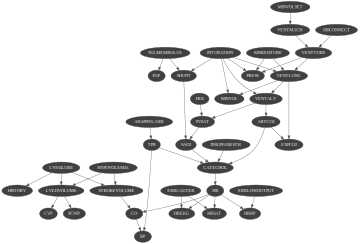

In [12]:
## Imprimimos el DAG
gnb.showBN(bn)

En este caso la red bayesiana ya está dada. Abajo está la base de datos que explica cada una de las variables

In [11]:
# Vemos las variables y su descripción
variables = pd.read_csv('https://raw.githubusercontent.com/VioletteGL/Interpretabiidad-y-Causalidad-Bourbaki/refs/heads/main/dic_alarm.csv',
                        usecols = ['id','nombre','descripcion','categorias','clase'],
                        index_col = ['id'])
variables

,nombre,descripcion,clase,categorias
id,,,,
1,CVP,central venous pressure,Evidencia,"LOW , NORMAL , HIGH"
2,PCWP,pulmonary capillary wedge pressure,Evidencia,"LOW , NORMAL , HIGH"
3,HISTORY,history,Evidencia,"TRUE , FALSE"
4,TPR,total peripheral resistance,Evidencia,"LOW , NORMAL , HIGH"
5,BP,blood pressure,Evidencia,"LOW , NORMAL , HIGH"
6,CO,cardiac output,Evidencia,"LOW , NORMAL , HIGH"
7,HRBP,heart rate / blood pressure,Evidencia,"LOW , NORMAL , HIGH"
8,HREKG,heart rate measured by an EKG monitor,Evidencia,"LOW , NORMAL , HIGH"
9,HRSAT,heart rate / oxygen saturation,Evidencia,"LOW , NORMAL , HIGH"


# Exploración de la Red Bayesiana

Link a la documentación de PyAgrum [link text](https://pyagrum.readthedocs.io/en/2.3.2/notebooks/02-Tutorial_Using_pyAgrum.html)

#### 1. Exploración de la red bayesiana.

- ¿Cuántas variables y dependencias entre variables hay en la red?



#### 2. Muestra la estructura de la Red Bayesiana

- ¿Cuáles nodos no tienen padres y cómo los interpretas?
- ¿Cuál nodo tiene más hijos directos?
- ¿Existe algún nodo que sea tanto hijo como padre? ¿De quién?
- ¿Mediante cuántos caminos puedes llegar de HYPOVOLEMIA a BP?


#### 3. ¿Cuáles son las variables clasificadas como "Alarma"?

# Diagnóstico vs predicción

#### 4. ¿Cuál es la probabilidad de tener insuficiencia ventricular izquierda (LVFAILURE)?

In [ ]:
### Sugerencia: Utiliza Lazy Propagator para hacer la inferencia. Lazy Propagator responde a la pregunta:
### "Dada cierta evidencia, ¿Cuál es la distrubución de probabilidad de esta variable?"
### https://pyagrum.readthedocs.io/en/2.3.2/BNInference.html#lazy-propagation
### Su eficiencia se debe a que no calcula el posterior de todas las variables a la vez,
### solo calcula la distribución de la variable que se le indica.


Recuerda que la lista de evidencias para pyAgrum debe tener forma de diccionario. Ejemplo:

```
evs_dict = {  'CVP': 2,
 'PCWP': 2,
 'HISTORY': 0,
 'TPR': 0,
 'HREKG': 2,
 'HRSAT':  1}
 ```



#### 5. Dado que hay LVFAILURE = TRUE, ¿Qué valores se esperan de CVP y PCWP?

#### 6. ¿Qué puedes concluir de la desigualdad?

$$ \mathbb{P}(LVFAILURE | CVP=LOW) \neq \mathbb{P}(CVP=LOW | LVFAILURE=TRUE) $$

#### 7. La presión de enclavamiento capilar pulmonar (PCWP), también conocida como presión de cuña pulmonar, es una medición hemodinámica que estima la presión en la aurícula izquierda y la presión diastólica final del ventrículo izquierdo.

#### Considerando el siguiente cuadro clínico:
- presión venosa central baja (CVP = LOW) y
- presión de enclavamiento capilar pulmonar baja (PCWP = LOW),

#### ¿Cuál es la probabilidad de tener insuficiencia ventricular izquierda (LVFAILURE)?

#### 8. ¿Te hace sentido el resultado anterior? Justifica tu respuesta.

Cada flecha en esta red responde a la pregunta del do-calculus de Judea Pearl: $P(Y | do(X)) \neq P(Y)$. Si intervenir sobre X cambia Y pero no al revés, la flecha va de X a Y.

+ ¿Son suficientes CVP y PCWP para diagnosticar LVFAILURE?
* ¿qué evidencia sí seriviría para diagnosticar LVFAILURE?

#### 9. Considerando el siguiente cuadro clínico:
- presión venosa central alta (CVP = HIGH)
- presión de enclavamiento capilar pulmonar alta (PCWP = HIGH),
- presión arterial baja (BP=LOW)
- 'output cardiaco' bajo (CO=LOW)

#### ¿Cuál es la prababilidad de padecer hipovolemia?

* ¿Qué evidencia discrimina entre LVFAILURE e HYPOVOLEMIA?

# D-separación

####10. Muestra que BP depende directamente de STROKEVOLUME y de TPR.

Si conocemos exactamente los valores de STROKEVOLUME y de TPR, ¿HYPOVOLEMIA da información adicional sobre BP?

Responde comparando `ie.posterior("BP")` con y sin evidencia sobre hypovolemia, fijando STROKEVOLUME.

* ¿Qué tipo de nodo de D-separación es STROKEVOLUME en este ejemplo?  

In [ ]:
### bn.cpt(bn.idFromName('BP'))